### Data Mining with K-Means Clustering

By Stephanie Nguyen

### A1. PROPOSAL OF QUESTION

How can K-means clustering on customer tenure and monthly charges in a churn dataset be applied to segment customers? 

### A2. DEFINED GOAL
The primary goal of this analysis is to use K-means clustering to gain a deeper understanding of telecom customer characteristics by analyzing their behavior. 

### B1.EXPLANATION OF CLUSTERING TECHNIQUE
K-means is an unsupervised machine learning technique used to group unlabeled data into clusters, commonly applied in areas like customer segmentation. In this analysis, K-means clustering was implemented using scipy to examine the churn dataset. Cluster centers, or centroids, were defined using the kmeans method, while cluster labels were assigned using vq from scipy.cluster.vq. 

### B2. SUMMARY OF TECHNIQUE ASSUMPTION
K-means assumes that all clusters have similar variance, meaning the algorithm expects clusters to be of similar size and shape, typically spherical.

### B3. PACKAGES OR LIBRARIES LIST



In [ ]:
# Importing all libraries and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import kmeans and vq functions
from scipy.cluster.vq import kmeans, vq

# Import the whiten function
from scipy.cluster.vq import whiten

# Import the silhouette score metric from scikit-learn
from sklearn.metrics import silhouette_score

In [ ]:
# Load Data
# import churn_clean.csv data set
df = pd.read_csv(r"C:\Users\steph\Documents\GitHub\Data Analysis\9. Unsupervised Machine Learing with K-Means Clustering in Python\Data\churn_clean.csv", keep_default_na=False,na_values=['NaN'])

### C1. DATA PREPROCESSING

In [ ]:
# Get the number of rows and columns in the dataframe
df.shape

(10000, 50)

In [ ]:
# preview the data
pd.set_option('display.max_columns',None)
df.head()

,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,Population,Area,TimeZone,Job,Children,Age,Income,Marital,Gender,Churn,Outage_sec_perweek,Email,Contacts,Yearly_equip_failure,Techie,Contract,Port_modem,Tablet,InternetService,Phone,Multiple,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,PaymentMethod,Tenure,MonthlyCharge,Bandwidth_GB_Year,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8
0,1,K409198,aa90260b-4141-4a24-8e36-b04ce1f4f77b,e885b299883d4f9fb18e39c75155d990,Point Baker,AK,Prince of Wales-Hyder,99927,56.25100,-133.37571,38,Urban,America/Sitka,Environmental health practitioner,0,68,28561.99,Widowed,Male,No,7.978323,10,0,1,No,One year,Yes,Yes,Fiber Optic,Yes,No,Yes,Yes,No,No,No,Yes,Yes,Credit Card (automatic),6.795513,172.455519,904.536110,5,5,5,3,4,4,3,4
1,2,S120509,fb76459f-c047-4a9d-8af9-e0f7d4ac2524,f2de8bef964785f41a2959829830fb8a,West Branch,MI,Ogemaw,48661,44.32893,-84.24080,10446,Urban,America/Detroit,"Programmer, multimedia",1,27,21704.77,Married,Female,Yes,11.699080,12,0,1,Yes,Month-to-month,No,Yes,Fiber Optic,Yes,Yes,Yes,No,No,No,Yes,Yes,Yes,Bank Transfer(automatic),1.156681,242.632554,800.982766,3,4,3,3,4,3,4,4
2,3,K191035,344d114c-3736-4be5-98f7-c72c281e2d35,f1784cfa9f6d92ae816197eb175d3c71,Yamhill,OR,Yamhill,97148,45.35589,-123.24657,3735,Urban,America/Los_Angeles,Chief Financial Officer,4,50,9609.57,Widowed,Female,No,10.752800,9,0,1,Yes,Two Year,Yes,No,DSL,Yes,Yes,No,No,No,No,No,Yes,Yes,Credit Card (automatic),15.754144,159.947583,2054.706961,4,4,2,4,4,3,3,3
3,4,D90850,abfa2b40-2d43-4994-b15a-989b8c79e311,dc8a365077241bb5cd5ccd305136b05e,Del Mar,CA,San Diego,92014,32.96687,-117.24798,13863,Suburban,America/Los_Angeles,Solicitor,1,48,18925.23,Married,Male,No,14.913540,15,2,0,Yes,Two Year,No,No,DSL,Yes,No,Yes,No,No,No,Yes,No,Yes,Mailed Check,17.087227,119.956840,2164.579412,4,4,4,2,5,4,3,3
4,5,K662701,68a861fd-0d20-4e51-a587-8a90407ee574,aabb64a116e83fdc4befc1fbab1663f9,Needville,TX,Fort Bend,77461,29.38012,-95.80673,11352,Suburban,America/Chicago,Medical illustrator,0,83,40074.19,Separated,Male,Yes,8.147417,16,2,1,No,Month-to-month,Yes,No,Fiber Optic,No,No,No,No,No,Yes,Yes,No,No,Mailed Check,1.670972,149.948316,271.493436,4,4,4,3,4,4,4,5


In [ ]:
# get overview of columns and data types in dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CaseOrder             10000 non-null  int64  
 1   Customer_id           10000 non-null  object 
 2   Interaction           10000 non-null  object 
 3   UID                   10000 non-null  object 
 4   City                  10000 non-null  object 
 5   State                 10000 non-null  object 
 6   County                10000 non-null  object 
 7   Zip                   10000 non-null  int64  
 8   Lat                   10000 non-null  float64
 9   Lng                   10000 non-null  float64
 10  Population            10000 non-null  int64  
 11  Area                  10000 non-null  object 
 12  TimeZone              10000 non-null  object 
 13  Job                   10000 non-null  object 
 14  Children              10000 non-null  int64  
 15  Age                 

In [ ]:
# detect null values
df.isnull().sum()

CaseOrder               0
Customer_id             0
Interaction             0
UID                     0
City                    0
State                   0
County                  0
Zip                     0
Lat                     0
Lng                     0
Population              0
Area                    0
TimeZone                0
Job                     0
Children                0
Age                     0
Income                  0
Marital                 0
Gender                  0
Churn                   0
Outage_sec_perweek      0
Email                   0
Contacts                0
Yearly_equip_failure    0
Techie                  0
Contract                0
Port_modem              0
Tablet                  0
InternetService         0
Phone                   0
Multiple                0
OnlineSecurity          0
OnlineBackup            0
DeviceProtection        0
TechSupport             0
StreamingTV             0
StreamingMovies         0
PaperlessBilling        0
PaymentMetho

In [ ]:
# get duplicates across all columns
df.duplicated().value_counts()

False    10000
Name: count, dtype: int64

### C2. DATA SET VARIABLES

In [ ]:
# create dataframe with selected features
columns = ['Tenure','MonthlyCharge']
df_subset = df[columns]

In [ ]:
# Tenure is the number of months a customer stayed with its provider
df_subset['Tenure'].describe().round(2)

count    10000.00
mean        34.53
std         26.44
min          1.00
25%          7.92
50%         35.43
75%         61.48
max         72.00
Name: Tenure, dtype: float64

In [ ]:
# MonthlyCharge is the amount a customer is charged monthly (average per customer). 
df_subset['MonthlyCharge'].describe().round(2)

count    10000.00
mean       172.62
std         42.94
min         79.98
25%        139.98
50%        167.48
75%        200.73
max        290.16
Name: MonthlyCharge, dtype: float64

In [ ]:
# Use the whiten() function to standardize the data
scaled_data = whiten(df_subset.values)
print(scaled_data)

[[0.25699946 4.0161089 ]
 [0.04374451 5.65037736]
 [0.59580587 3.72482664]
 ...
 [1.79325904 3.95832212]
 [2.68876401 5.88305611]
 [2.39586574 5.06472297]]


In [ ]:
# create a dataframe with the normalized data
df_clean = pd.DataFrame(scaled_data, columns=columns)
df_clean.head()

,Tenure,MonthlyCharge
0,0.256999,4.016109
1,0.043745,5.650377
2,0.595806,3.724827
3,0.646222,2.793530
4,0.063194,3.491966


### C4. CLEANED DATA SET

In [ ]:
# View and export the cleaned data set
df_clean.to_csv(r"C:\Users\steph\Documents\GitHub\Data Analysis\9. Unsupervised Machine Learing with K-Means Clustering in Python\Output\df_clean.csv",index=False)

### D1. OUTPUT AND INTERMEDIATE CALCULATIONS

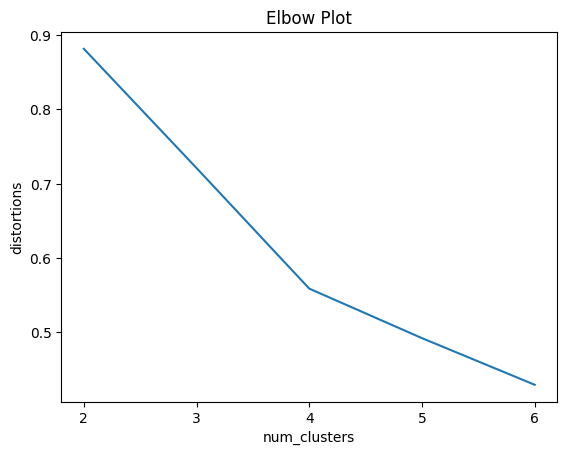

In [ ]:
distortions = []
num_clusters = range(2, 7)

# Create a list of distortions from the kmeans function
for i in num_clusters:
    cluster_centers, distortion = kmeans(df_clean,i)
    distortions.append(distortion)

# Create a DataFrame with two lists - number of clusters and distortions
elbow_plot = pd.DataFrame({'num_clusters': num_clusters, 'distortions': distortions})

# Creat a line plot of num_clusters and distortions
sns.lineplot(x='num_clusters', y='distortions', data=elbow_plot)
plt.xticks(num_clusters)
plt.title('Elbow Plot')
plt.savefig('Elbow Plot.png',bbox_inches='tight')
plt.show()

### D2. CODE EXECUTION

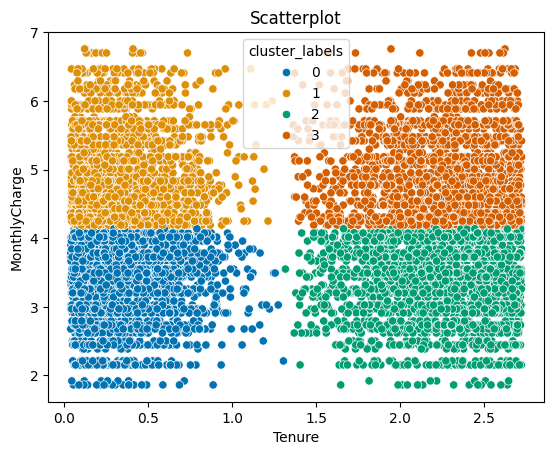

In [ ]:
# K-MEANS CLUSTERING

# Generate cluster centers
cluster_centers, distortion = kmeans(df_clean, 4, seed = 300)

# Assign cluster labels
df_clean['cluster_labels'], distortion_list = vq(df_clean, cluster_centers)

# Plot clusters
sns.scatterplot(x='Tenure', y='MonthlyCharge', 
                hue='cluster_labels', palette = 'colorblind', data = df_clean)

plt.title('Scatterplot')
plt.savefig('Scatterplot.png',bbox_inches='tight')

In [ ]:
df_clean.groupby('cluster_labels').count()

,Tenure,MonthlyCharge
cluster_labels,,
0,2931,2931
1,2068,2068
2,2978,2978
3,2023,2023


### E1. QUALITY OF THE CLUSTERING TECHNIQUE

In [ ]:
sil_score = silhouette_score(scaled_data, df_clean['cluster_labels']).round(2)
print(f'Silhouette Score: {sil_score}')

Silhouette Score: 0.5


- The silhouette score evaluates clustering quality on a scale from -1 to 1.
- 1 indicates optimal clustering, while -1 signifies poor cluster assignments.
- A score near 0 suggests overlapping clusters.
- In this case, a silhouette score of 0.5 was calculated using scikit-learn, indicating moderate clustering performance with some overlap or ambiguity.

### E2. RESULTS AND IMPLICATIONS
These clusters represent the following customer types:

1.	Short-tenure, low-payment customers

2.	Short-tenure, high-payment customers

3.	Long-tenure, low-payment customers

4.	Long-tenure, high-payment customers

### E3. LIMITATION
- There is no single method for determining the optimal number of clusters in K-means clustering.
- In this analysis, the elbow plot was used, but it may be ineffective for evenly distributed data that lacks a clear elbow point.
- Alternative methods, like the gap statistic or average silhouette score, can be more reliable for identifying the optimal number of clusters.

### E4. COURSE OF ACTION
- Provide personalized offers or discounts to high-paying new customers to reduce churn.
- Implement loyalty programs for long-term, high-value customers to maintain engagement.
- Continuously monitor customer behavior to adjust strategies as needed.